# **Assignment 1 – Simple Linear Regression**
**Goal:** Understand the basics of regression by creating your own dataset.

### Steps:
1. Formulate your own equation in the form:  
   $
   y = m x + c
   $
   
   Example: $y = 2x + 3$
2. Generate X values (at least 100 numbers between your chosen range).
3. Generate Y values using your equation.
4. Add small random noise to Y to make it realistic.
5. Split data into train and test splits
6. Fit a Simple Linear Regression model.
7. Print learned coefficient and intercept.
8. Split the data into train and test sets (80%-20%).
9. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.
10. Visualize the points and the fitted line.


In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
np.random.seed(42)
 
X =np.random.randint(1,1000,10000).reshape(-1,1)
y = 10*X +20 + np.random.randn(10000,1) * 10


In [3]:
X.shape

(10000, 1)

In [4]:
y.shape

(10000, 1)

In [5]:
X_train,X_test,y_train,y_test =train_test_split(X , y , test_size=.2 , random_state=42)


In [6]:
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)

LinearRegression()

In [7]:
lin_model.coef_

array([[9.99946915]])

In [8]:
lin_model.intercept_

array([20.22002132])

In [9]:
y_train_pred = lin_model.predict(X_train)
lin_predictions = lin_model.predict(X_test)


# The model beacause it's high range and medium size data it suffers outliers so the MSE is highily effected through outliers in both train and test but it reduces much in MAE and RMSE because it doesn't effect outliers much so the r squared score is nearly 1 in train and test so the model performed well 

In [10]:
print(f"Train Mean Squared Error {mean_squared_error(y_train,y_train_pred)}")
print(f"Train Mean Absolute Error {mean_absolute_error(y_train,y_train_pred)}")
print(f"Train Root Mean Squared Error {root_mean_squared_error(y_train,y_train_pred)}")
print(f"Train R Squared {r2_score(y_train,y_train_pred)}")

Train Mean Squared Error 100.96292123819612
Train Mean Absolute Error 8.046708164488265
Train Root Mean Squared Error 10.048030714433358
Train R Squared 0.9999880272261524


In [11]:
print(f"Test Mean Squared Error {mean_squared_error(y_test,lin_predictions)}")
print(f"Test Mean Absolute Error {mean_absolute_error(y_test,lin_predictions)}")
print(f"Test Root Mean Squared Error {root_mean_squared_error(y_test,lin_predictions)}")
print(f"Test R Squared {r2_score(y_test,lin_predictions)}")

Test Mean Squared Error 97.3198841238379
Test Mean Absolute Error 7.898347049674053
Test Root Mean Squared Error 9.865084091067743
Test R Squared 0.9999881344202002


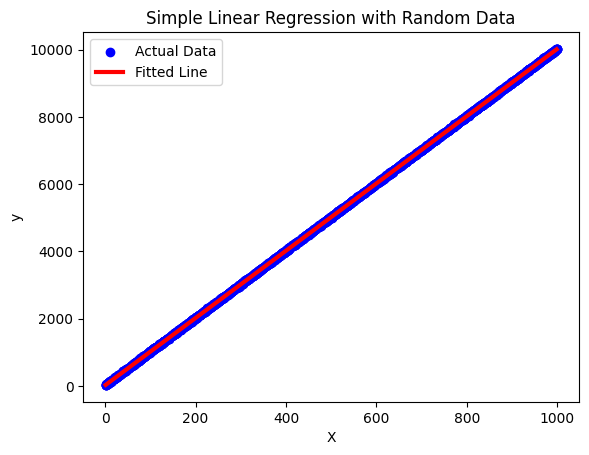

In [12]:
sorted_idx = np.argsort(X_test.ravel())
X_test_sorted = X_test[sorted_idx]
lin_predictions_sorted = lin_predictions[sorted_idx]

plt.scatter(X_test, y_test, color='blue', alpha=1, label='Actual Data')
plt.plot(X_test_sorted, lin_predictions_sorted, color='red', linewidth=3, label='Fitted Line')
plt.title('Simple Linear Regression with Random Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# **Assignment 2 – Multiple Linear Regression**
**Goal:** See how multiple features affect predictions.

### Steps:
1. Formulate your own equation:
   $
   y = a_1 x_1 + a_2 x_2 + c
   $
2. Generate `x1` and `x2` values (at least 100 numbers each).
3. Generate Y values with noise.
4. Split data into train and test splits
5. Fit a Multiple Linear Regression model.
6. Compare coefficients and intercept to your original equation.
7. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.



In [13]:
x1 = np.random.randint(1,10,10000).reshape(-1,1)
x2 = np.random.randint(100,1000,10000).reshape(-1,1)
y = (20*x1)+(5*x2) +100 +np.random.randn(10000, 1) * 20


In [14]:
X = np.hstack((x1, x2))  

In [15]:
X.shape

(10000, 2)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.55276398,  1.56920672],
       [-1.58033525, -1.70690826],
       [-0.79706045,  0.09091277],
       ...,
       [-0.40542304,  1.51146086],
       [-0.01378564,  0.94940118],
       [-0.40542304,  0.35654371]])

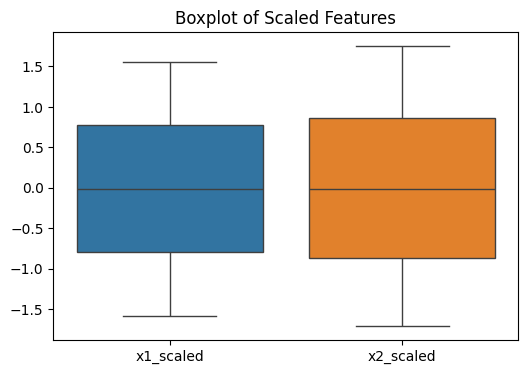

In [17]:
import pandas as pd
# Convert scaled features into a DataFrame with column names
df = pd.DataFrame(X_scaled, columns=["x1_scaled", "x2_scaled"])

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(data=df)
plt.title("Boxplot of Scaled Features")
plt.show()

In [18]:
multi_model =LinearRegression()
X_train,X_test,y_train,y_test =train_test_split(X_scaled , y , test_size=.3 , random_state=42)
multi_model.fit(X_train,y_train)


LinearRegression()

In [19]:
print(f"Coefient :{multi_model.coef_}")

Coefient :[[  50.74597775 1298.9618157 ]]


In [20]:
print(f"Intercept :{multi_model.intercept_}")

Intercept :[2922.13868356]


In [21]:
y_train_pred_mulit = multi_model.predict(X_train)
multi_predictions = multi_model.predict(X_test)


# here the r squared show perfect model in training and testing but the MSE don't that's because even if our features scaled and don't have outliers the noise added to the y made the error with std in y =20 the RMSE is 20 also 

In [22]:
print(f"Train Mean Squared Error {mean_squared_error(y_train,y_train_pred_mulit)}")
print(f"Train Mean Absolute Error {mean_absolute_error(y_train,y_train_pred_mulit)}")
print(f"Train Root Mean Squared Error {root_mean_squared_error(y_train,y_train_pred_mulit)}")
print(f"Train R Squared {r2_score(y_train,y_train_pred_mulit)}")

Train Mean Squared Error 409.98060055243303
Train Mean Absolute Error 16.161380940217892
Train Root Mean Squared Error 20.247977690436965
Train R Squared 0.9997589491832911


In [23]:
print(f"Test Mean Squared Error {mean_squared_error(y_test,multi_predictions)}")
print(f"Test Mean Absolute Error {mean_absolute_error(y_test,multi_predictions)}")
print(f"Test Root Mean Squared Error {root_mean_squared_error(y_test,multi_predictions)}")
print(f"Test R Squared {r2_score(y_test,multi_predictions)}")

Test Mean Squared Error 414.27270057404274
Test Mean Absolute Error 16.301498554111653
Test Root Mean Squared Error 20.35369009722912
Test R Squared 0.999750553776066


# **Assignment 3 – Polynomial Regression**
**Goal:** Model non-linear relationships.

### Steps:
1. Formulate your own equation:
   $
   y = ax^2 + bx + c
   $
2. Generate X values and Y values with noise.
3. Use `PolynomialFeatures` to transform X.
4. Split the data into train and test sets (80%-20%).
5. Fit a Linear Regression model on transformed features.
6. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.



In [24]:
poly_x = np.random.randint(20,80,10000).reshape(-1,1)
poly_y = 20*(poly_x**2) + 50 *poly_x +80 +np.random.randn(10000, 1) * 5

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(poly_x)

In [26]:
print(poly.get_feature_names_out())

['1' 'x0' 'x0^2']


In [27]:
poly_model =LinearRegression()
X_train,X_test,y_train,y_test =train_test_split(X_poly , poly_y , test_size=.3 , random_state=42)
poly_model.fit(X_train,y_train)

LinearRegression()

In [28]:
# Make predictions
poly_predictions = poly_model.predict(X_test)
y_train_pred_poly = poly_model.predict(X_train)


In [29]:
print(f"Train Mean Squared Error {mean_squared_error(y_train,y_train_pred_poly)}")
print(f"Train Mean Absolute Error {mean_absolute_error(y_train,y_train_pred_poly)}")
print(f"Train Root Mean Squared Error {root_mean_squared_error(y_train,y_train_pred_poly)}")
print(f"Train R Squared {r2_score(y_train,y_train_pred_poly)}")

Train Mean Squared Error 25.082060480059273
Train Mean Absolute Error 4.0086926797372895
Train Root Mean Squared Error 5.008199325112697
Train R Squared 0.9999999796683311


In [30]:
print(f"Test Mean Squared Error {mean_squared_error(y_test,poly_predictions)}")
print(f"Test Mean Absolute Error {mean_absolute_error(y_test,poly_predictions)}")
print(f"Test Root Mean Squared Error {root_mean_squared_error(y_test,poly_predictions)}")
print(f"Test R Squared {r2_score(y_test,poly_predictions)}")

Test Mean Squared Error 24.573413385866132
Test Mean Absolute Error 3.9873720124463556
Test Root Mean Squared Error 4.957157793117557
Test R Squared 0.999999980973094


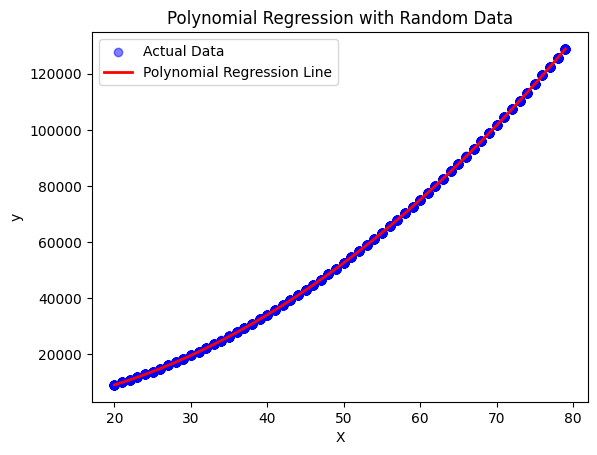

In [31]:
# Sort X_test for proper plotting
sorted_idx = np.argsort(X_test[:, 1])   # use the x feature (not the bias or x^2)
X_test_sorted = X_test[sorted_idx]
poly_predictions_sorted = poly_predictions[sorted_idx]

# Plot actual vs predicted
plt.scatter(X_test[:, 1], y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test_sorted[:, 1], poly_predictions_sorted, color='red', linewidth=2, label='Polynomial Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression with Random Data')
plt.legend()
plt.show()

## Machine Learning Project Pipeline

### 1. **Exploratory Data Analysis (EDA)**
- Inspect dataset structure (`.info()`, `.describe()`)
- Check for missing values and duplicates
- Understand feature types (numeric, categorical, datetime, etc.)
- Visualize data distributions (histograms, boxplots, bar charts)
- Identify correlations between features and target
- Detect outliers and anomalies

---

### 2. **Data Cleaning**
- Handle missing values (drop, fill with mean/median/mode, or use predictive imputation)
- Remove duplicates
- Fix inconsistent data formats (e.g., date parsing, string trimming)
- Correct data entry errors or outliers (if verified)

---

### 3. **Data Pre-processing**
- Convert data types if necessary (e.g., `object` to `datetime` or numeric)
- Handle categorical variables:
  - **Encoding**:
    - One-Hot Encoding (for nominal categories)
    - Ordinal Encoding (for ordered categories)
- Verify numeric features:
  - Check for incorrect values (e.g., negative ages)
  - Apply transformations if needed (e.g., log transform for skewed data)

---

### 4. **Scaling Numeric Features**
- Standardization (`StandardScaler`) — mean = 0, std = 1
- Normalization (`MinMaxScaler`) — values between 0 and 1
- Robust Scaling (less sensitive to outliers)

---

### 5. **Splitting Data**
- **Train-Test Split**
  - Typically 70–80% for training, 20–30% for testing
  - Use `train_test_split` from `sklearn`
  - Set `random_state` for reproducibility
- Optional: create a **validation set** for model tuning

---

### 6. **Modeling**
- Choose model type based on task:
  - **Regression:** Linear Regression
- Train the model on training data (Your target is `price`)

---

### 7. **Evaluating the Model**
- **On Training Data**:
  - Evaluate for underfitting (low train performance)
- **On Testing Data**:
  - Evaluate for overfitting (high train, low test performance)
- Metrics:
  - **Regression:** MAE, MSE, RMSE, R²

---

### 8. **Final Steps**
- Save the model (`joblib` or `pickle`)



In [32]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("rohitgrewal/airlines-flights-data")

print("Path to dataset files:", path)

c:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Nour\.cache\kagglehub\datasets\rohitgrewal\airlines-flights-data\versions\1


In [33]:
os.listdir(path)

['airlines_flights_data.csv']

In [34]:
full_path = os.path.join(path,os.listdir(path)[0])

In [35]:
import pandas as pd
df = pd.read_csv(full_path)

In [36]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [37]:
df.drop("index",axis=1,inplace=True)

In [38]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [40]:
cats_columns =[]
for column in df.columns:
    if df[column].nunique() <10 :
        print(f"{column} values : {df[column].unique()}")
        print("*"*20)
        cats_columns.append(column)

airline values : ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
********************
source_city values : ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
********************
departure_time values : ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
********************
stops values : ['zero' 'one' 'two_or_more']
********************
arrival_time values : ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
********************
destination_city values : ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
********************
class values : ['Economy' 'Business']
********************


### airline => one hot 
### source => onehot
### depature => label 
### stops => label 
### arrival => label 
### destination => one hot 
### class => label

In [41]:
cats_columns

['airline',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

In [42]:
df.describe(include="all")

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [43]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [44]:
df.duplicated().sum()

0

In [45]:
df.shape

(300153, 11)

In [46]:
df['flight'].nunique()

1561

In [47]:
df.drop('flight',axis=1,inplace=True)

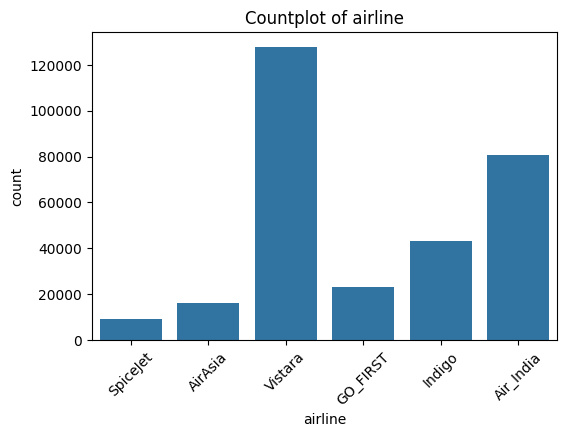

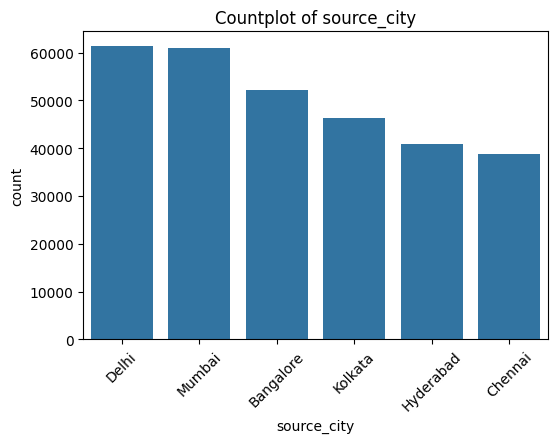

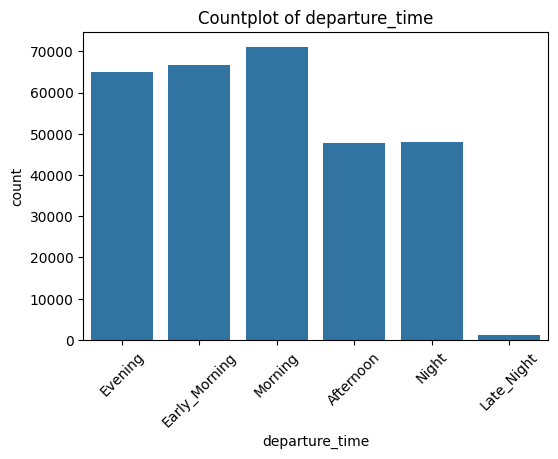

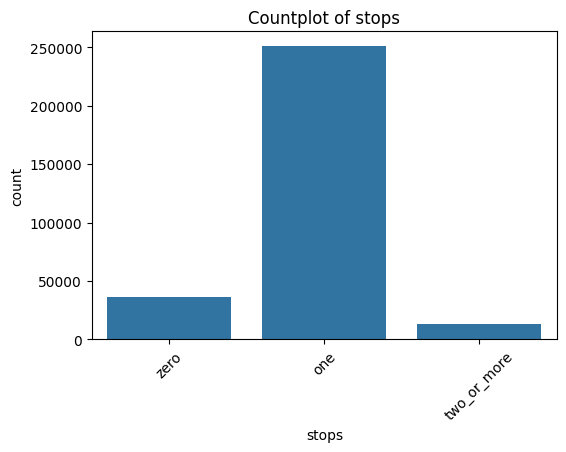

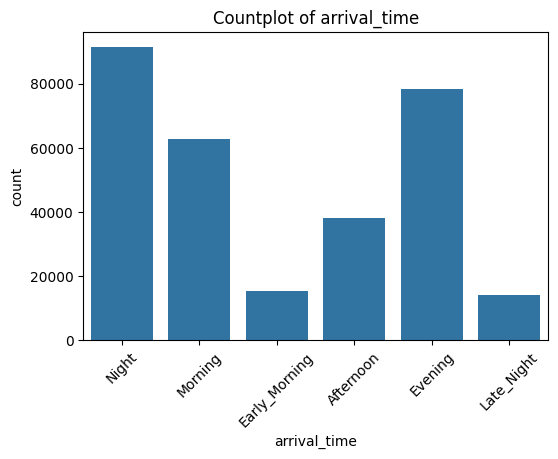

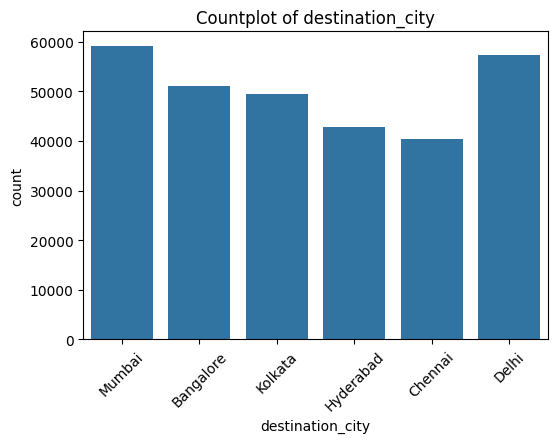

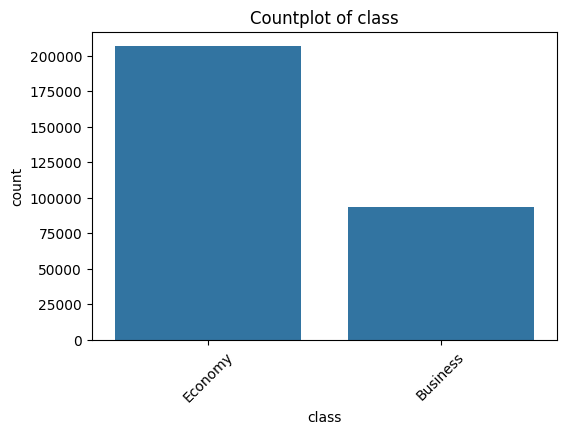

In [48]:
for col in cats_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

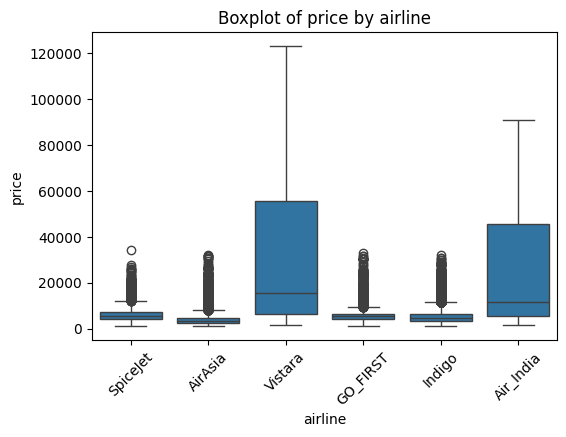

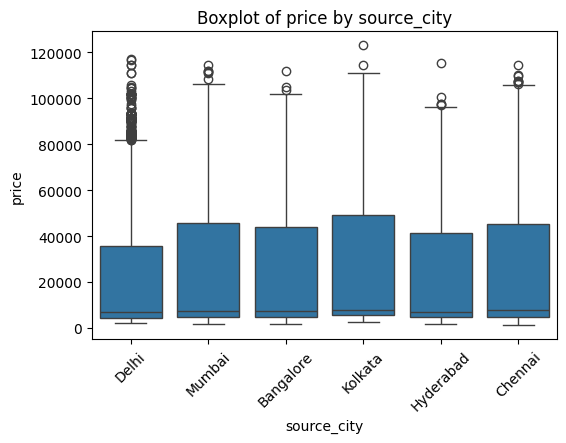

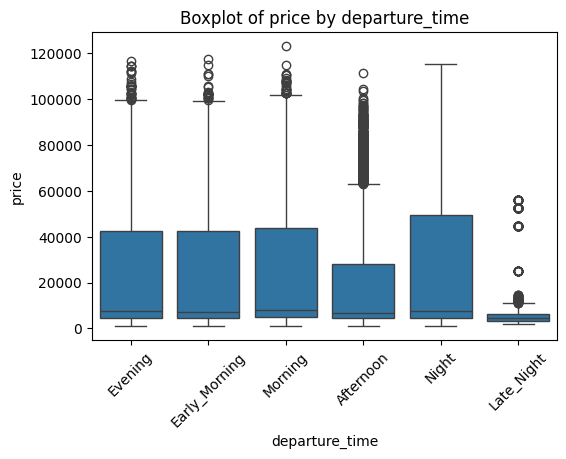

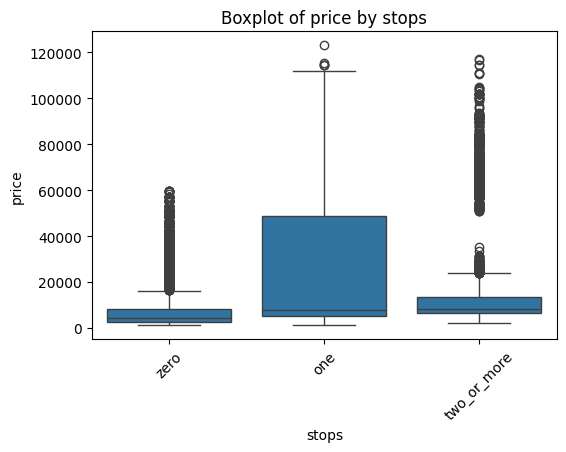

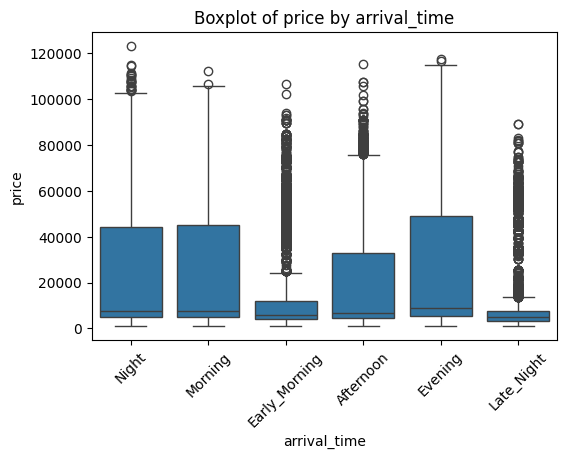

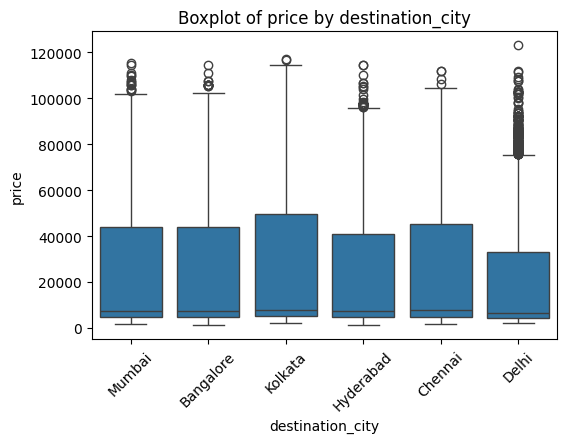

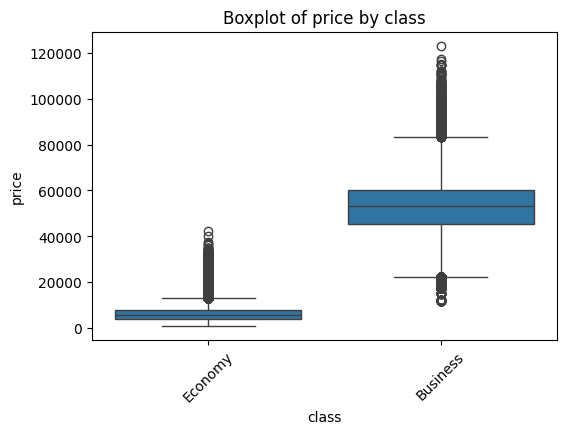

In [49]:
target = 'price'  # replace with your actual numeric target column
for col in cats_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"Boxplot of {target} by {col}")
    plt.xticks(rotation=45)
    plt.show()

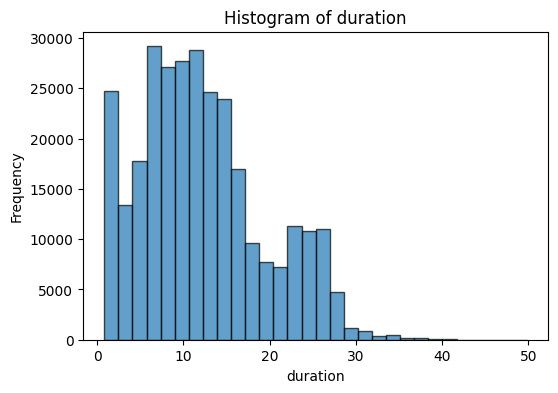

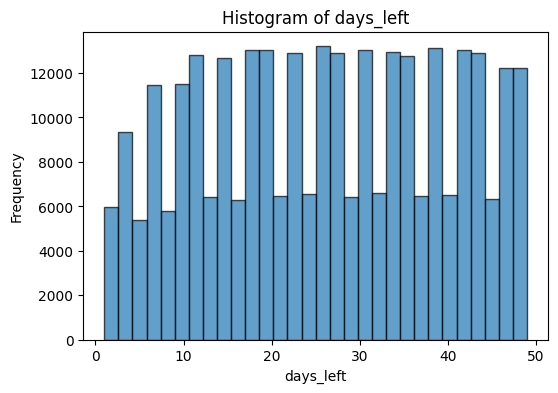

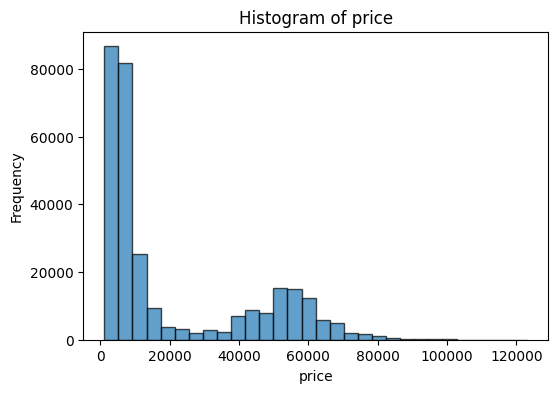

In [50]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

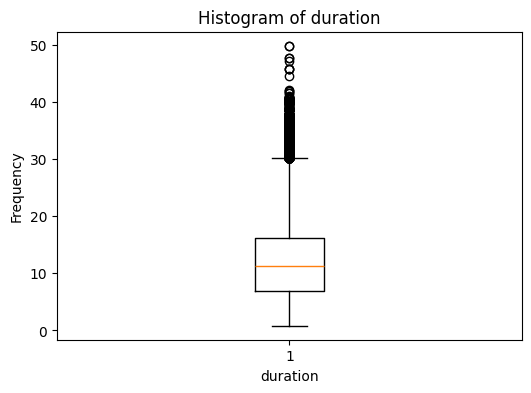

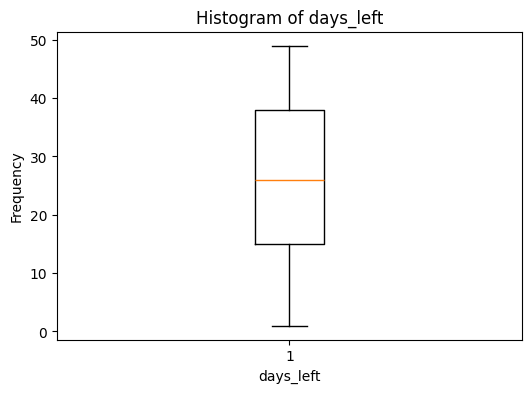

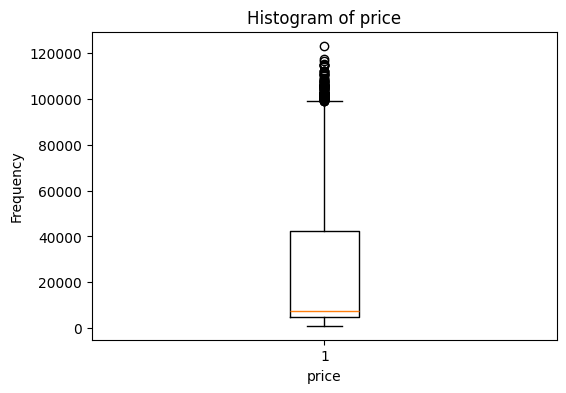

In [51]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

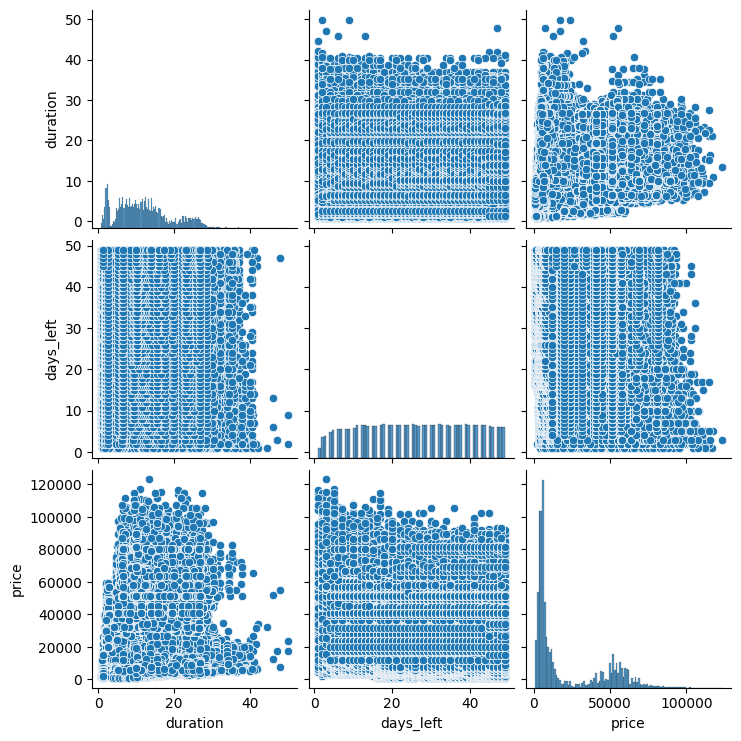

In [52]:
sns.pairplot(df[numeric_cols])

C:\Users\Nour\AppData\Local\Temp\ipykernel_19864\497030098.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="airline", y="price", hue="class", data=df, ci=None)


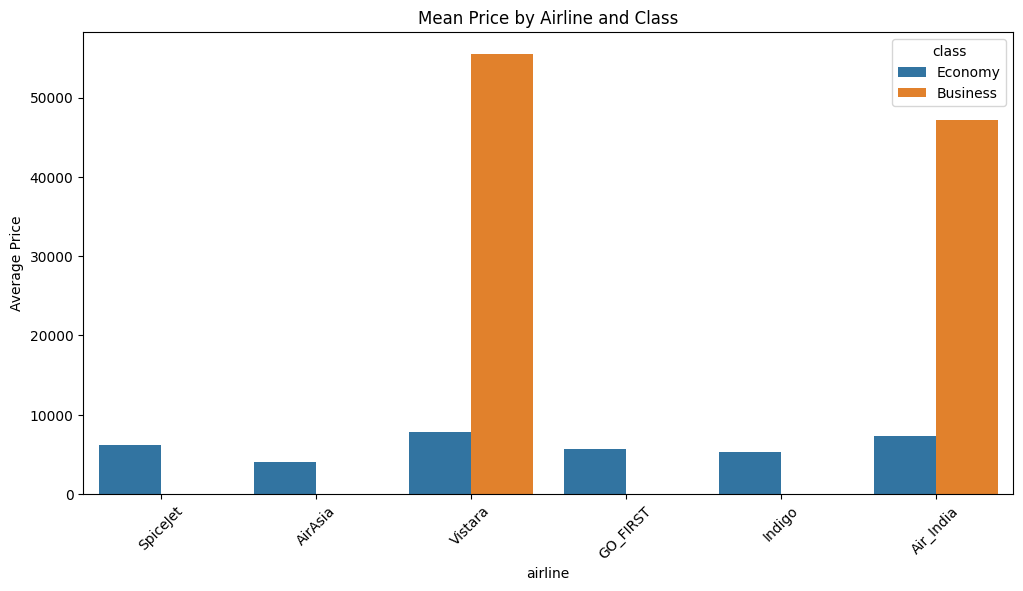

In [53]:
plt.figure(figsize=(12,6))
sns.barplot(x="airline", y="price", hue="class", data=df, ci=None)
plt.title("Mean Price by Airline and Class")
plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.show()


C:\Users\Nour\AppData\Local\Temp\ipykernel_19864\1710233062.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="source_city", y="price", hue="destination_city", data=route_means, ci=None)


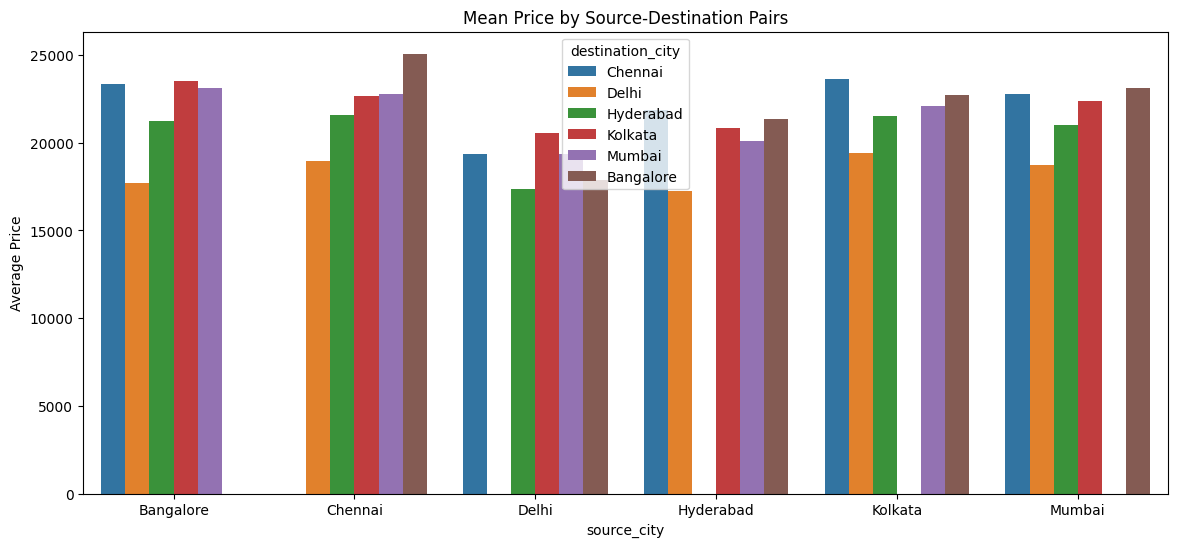

In [54]:
# Grouping
route_means = df.groupby(["source_city", "destination_city"])["price"].mean().reset_index()

# Plot
plt.figure(figsize=(14,6))
sns.barplot(x="source_city", y="price", hue="destination_city", data=route_means, ci=None)
plt.title("Mean Price by Source-Destination Pairs")
plt.ylabel("Average Price")
plt.show()


In [55]:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['duration'] >= lower) & (df['duration'] <= upper)]

df['price']=np.log1p(df['price'])

C:\Users\Nour\AppData\Local\Temp\ipykernel_19864\1639788027.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price']=np.log1p(df['price'])


In [56]:
df =pd.get_dummies(df,columns=['airline','source_city','destination_city'],drop_first=True)


In [57]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_mappings = {
    "departure_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
    "stops": ["zero", "one", "two_or_more"],
    "arrival_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
    "class": ["Economy", "Business"]
}
ordinal_cols =list(ordinal_mappings.keys())
ord_encoder = OrdinalEncoder(categories=list(ordinal_mappings.values()))

df[ordinal_cols] = ord_encoder.fit_transform(df[ordinal_cols])



In [58]:
df.head()

,departure_time,stops,arrival_time,class,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,3.0,0.0,4.0,0.0,2.17,1,8.691819,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,0.0,0.0,1.0,0.0,2.33,1,8.691819,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,0.0,0.0,0.0,0.0,2.17,1,8.692322,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,1.0,0.0,2.0,0.0,2.25,1,8.692154,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,1.0,0.0,1.0,0.0,2.33,1,8.692154,False,False,False,...,False,True,False,False,False,False,False,False,False,True


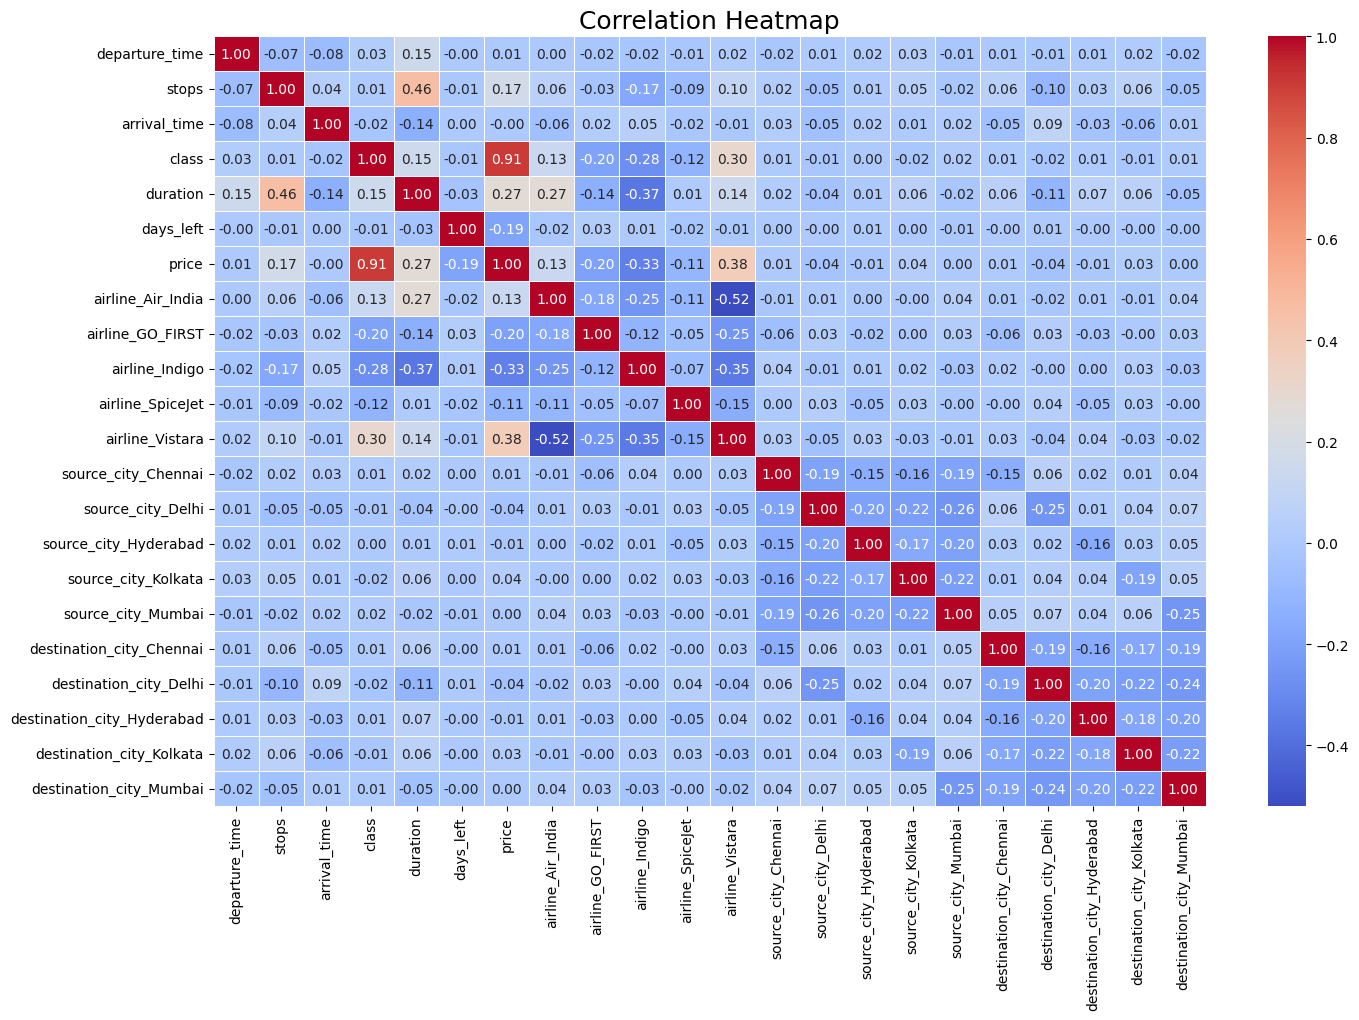

In [59]:
plt.figure(figsize=(16,10))   # 🔥 make it wide & tall
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

In [60]:
df.shape

(298043, 22)

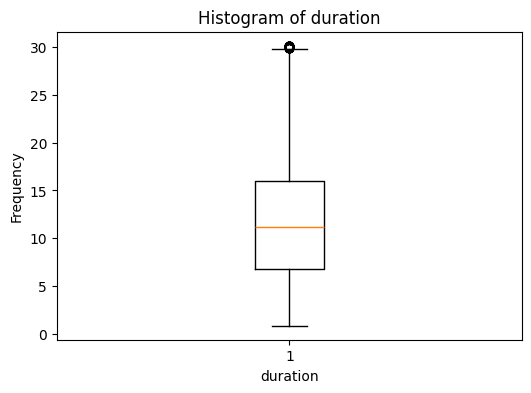

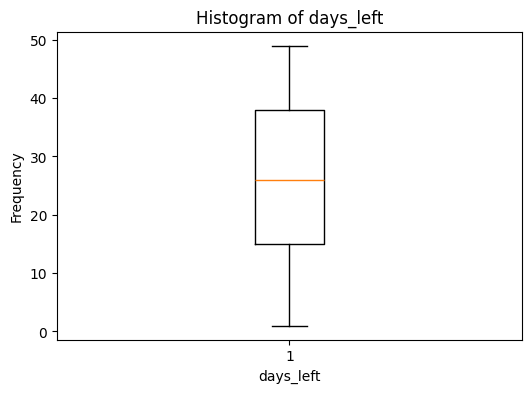

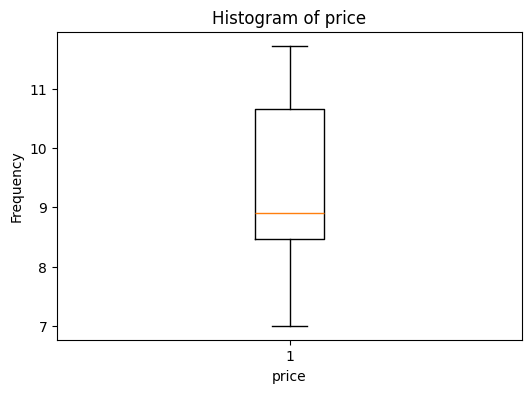

In [61]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [62]:
X = df.drop('price',axis=1)
y =df['price']
X_train,X_test,y_train,y_test =train_test_split(X , y , test_size=.3 , random_state=42)


In [63]:
flight_lin_model = LinearRegression()
flight_lin_model.fit(X_train,y_train)

LinearRegression()

In [64]:
flight_lin_model.coef_

array([-0.01046603,  0.37837178,  0.01756153,  2.03880554,  0.00480154,
       -0.01431509,  0.53856793,  0.4349449 ,  0.34993875,  0.48139023,
        0.66607523, -0.04616348, -0.02929075, -0.08582133,  0.14018747,
       -0.04573899, -0.04905635, -0.02078226, -0.09997968,  0.10760763,
       -0.02108596])

In [65]:
flight_lin_model.intercept_

8.126473279981624

In [66]:
y_train_pred = flight_lin_model.predict(X_train)
lin_predictions = flight_lin_model.predict(X_test)


In [67]:
print(f"Train Mean Squared Error {mean_squared_error(y_train,y_train_pred)}")
print(f"Train Mean Absolute Error {mean_absolute_error(y_train,y_train_pred)}")
print(f"Train Root Mean Squared Error {root_mean_squared_error(y_train,y_train_pred)}")
print(f"Train R Squared {r2_score(y_train,y_train_pred)}")

Train Mean Squared Error 0.1064624427882601
Train Mean Absolute Error 0.25597742874634927
Train Root Mean Squared Error 0.32628582989192173
Train R Squared 0.9143835114248433


In [68]:
print(f"Test Mean Squared Error {mean_squared_error(y_test,lin_predictions)}")
print(f"Test Mean Absolute Error {mean_absolute_error(y_test,lin_predictions)}")
print(f"Test Root Mean Squared Error {root_mean_squared_error(y_test,lin_predictions)}")
print(f"Test R Squared {r2_score(y_test,lin_predictions)}")

Test Mean Squared Error 0.10640991635810904
Test Mean Absolute Error 0.2560196015573367
Test Root Mean Squared Error 0.326205328525009
Test R Squared 0.9144368171585721


In [69]:
import joblib

# Save model
joblib.dump(flight_lin_model, "flight_poly_model.pkl")

['flight_poly_model.pkl']

## OPTIONAL SUGGESTIONS for Visualizations for Flight Price Dataset
> **YOU MUST MAKE VISUALIZATIONS. THESE ARE ONLY SUGGESTIONS**
### 1. **Numeric Data Visualizations**
(Columns: `duration`, `days_left`, `price`)

**a. Distribution of Numeric Features**
- **Histograms / KDE plots**  
  - Price distribution — check for skewness.  
  - Duration distribution — detect common flight lengths.  
  - Days left — reveal booking patterns.

**b. Boxplots for Outlier Detection**
- Boxplot of `price` — spot extreme values.
- Boxplot of `duration` grouped by `class` or `airline`.

**c. Price vs Numeric Feature Relationships**
- Scatter plot: `price` vs `duration` (color by `class` or `airline`).
- Scatter plot: `price` vs `days_left` (color by `class` or `stops`).

---

### 2. **Categorical Data Visualizations**
(Columns: `airline`, `flight`, `source_city`, `departure_time`, `stops`, `arrival_time`, `destination_city`, `class`)

**a. Price Trends by Category**
- **Boxplots**
  - `price` by `airline` — compare average fares.
  - `price` by `source_city` or `destination_city`.
  - `price` by `stops` — direct vs connecting flights.

**b. Frequency Counts**
- Bar plots of `airline` frequency — market share.
- Bar plots of `source_city` and `destination_city` — most common routes.
- Bar plots of `departure_time` (morning, afternoon, evening, night) — popular times.

**c. Grouped Statistics**
- Mean `price` by `airline` and `class` — grouped bar plots.
- Mean `price` by `(source_city, destination_city)` pairs.

---

### 3. **Mixed Insights**

**a. Heatmaps / Pivot Tables**
- Pivot table: average `price` for each `(source_city, destination_city)` pair — show as heatmap.
- Pivot table: average `price` for each `(airline, class)` — reveal premium vs economy gap.

**b. Correlation Heatmap (Numeric Only)**
- Show correlation between `duration`, `days_left`, and `price`.

---
*These visualizations can reveal pricing patterns, airline competitiveness, route popularity, and booking behavior trends.*
